In [1]:
%pwd
%load_ext autoreload
%autoreload 2

In [2]:
import sys
import os

project_root = os.path.abspath(os.path.join(os.getcwd(), "../../"))
if project_root not in sys.path:
    sys.path.insert(0, project_root)
from experiments.scripts.run_experiments import run_experiment
from experiments.scripts.experiment_utils import generate_experiments

INFO: NumExpr defaulting to 8 threads.


In [4]:
base_config = {
    # Experiment
    "experiment": "circle_low_for_plotting",
    "random_seed": 42,
    "logging": True,

    # Dataset
    "dataset_name": "s1_synthetic",
    "batch_size": 64,
    "rotation": "random",
    "translation": "random",
    "n_times": 10000,
    "embedding_dim": 10,
    "radius": 2,
    "noise_var": 0.0001,
    "n_wiggles": 5,
    "geodesic_distortion_amp": 0.3,
    "geodesic_distortion_func": "wiggles",  # Accepted values "wiggles" or "bump"

    # Model
    'model_type': 'EuclideanAE',
    "data_dim": 10,
    'latent_dim': 2,
    'sftbeta': 4.5,
    'device': "cpu",
    'encoder_widths': [100, 100, 100],
    'decoder_widths': [100, 100, 100],
    'activation': "softplus",

    # Optimizer
    "learning_rate": 0.001,

    # Trainer
    'verbose': False,
    'num_epochs': 100,
    'log_interval': 100,
    'recon_loss': "MSE",
    'topo_loss': True,
    'dim_topo_loss': 0,  # Max feature dimension topological loss
    'alpha': 1.0,  # Weight for reconstruction loss
    'beta': 0.0,  # Weight for KL loss
    'gamma': 0.0,  # Weight for topological loss

    # Curvature computation
    "plot_curvatures": True,
    "compute_emp_curv": True,
    "compute_true_curv": False,
    "compute_learned_curv": False,
    "compute_rec_curv": True,
    "quadric_dim": 1,
    "n_plot_points": 3000,
    "n_points_emp_curv": 3000,
    "n_points_pullback_curv": 3000, 
    "k": 130,
    "smoothing": False,

    # Persistent homology
    "persistent_homology": False,
    "n_points_pers_hom": 1000,
    "scale": False,
    "homology_dimensions": [0, 1]
}

param_grid = {
    "alpha": [1] + [1, 0] * 2,
    "gamma": [0] + [1, 1] * 2,
    "dim_topo_loss": [0] + [0] * 2 + [1] * 2,
}



all_configs = generate_experiments(base_config, param_grid)


Running exp00_circle_low_for_plotting. 
Description: alpha=1, gamma=0, dim_topo_loss=0
--------------------------------------------------------------------------------------


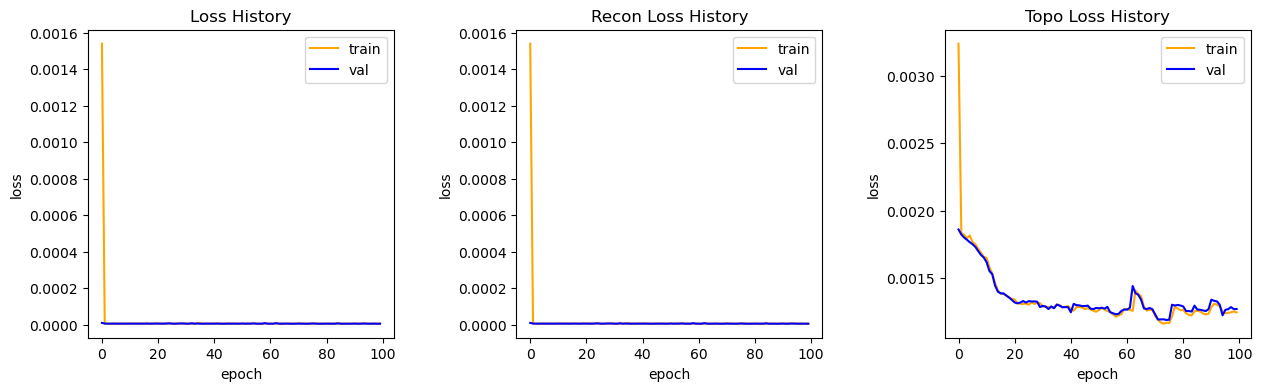

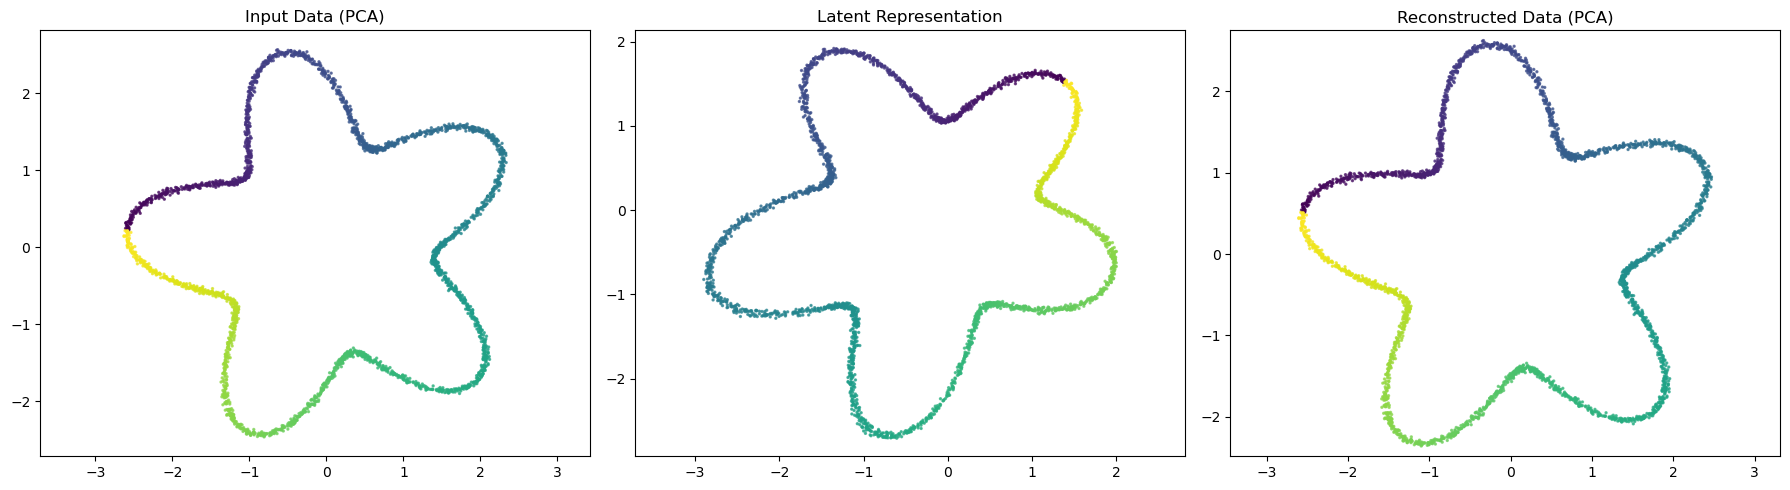

Estimating 1D curvature: 100%|████████████| 3000/3000 [00:02<00:00, 1181.81it/s]


<Figure size 640x480 with 0 Axes>

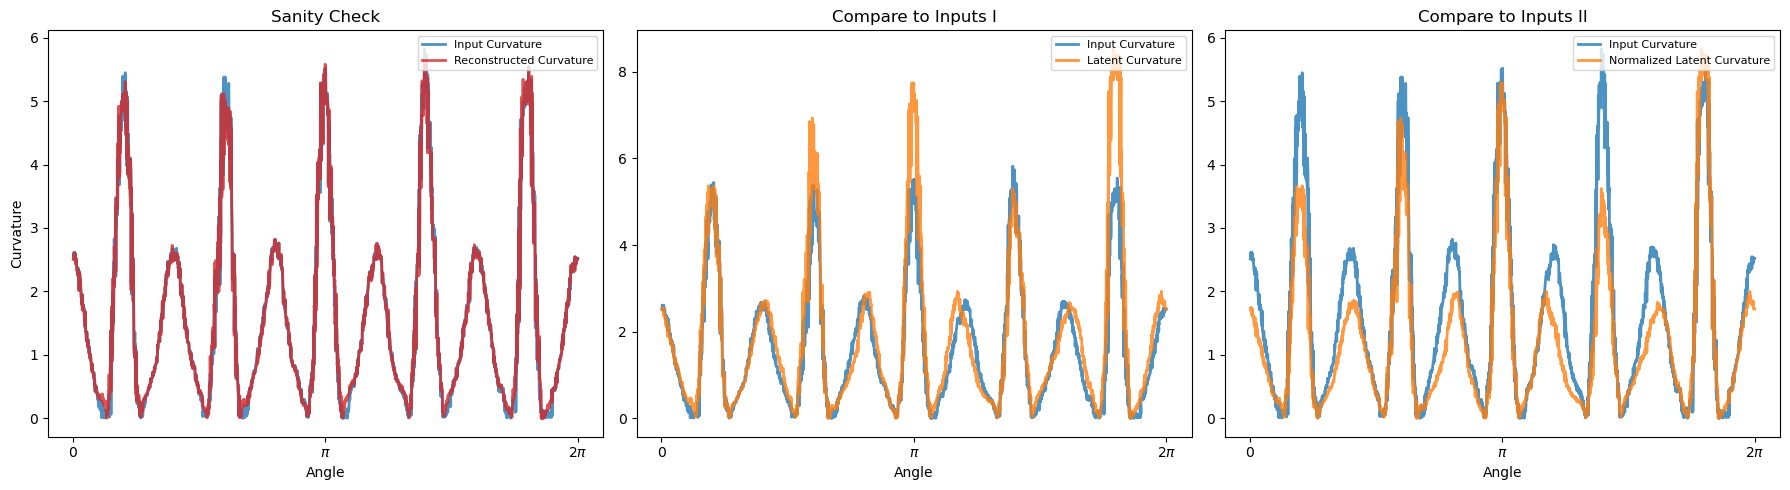

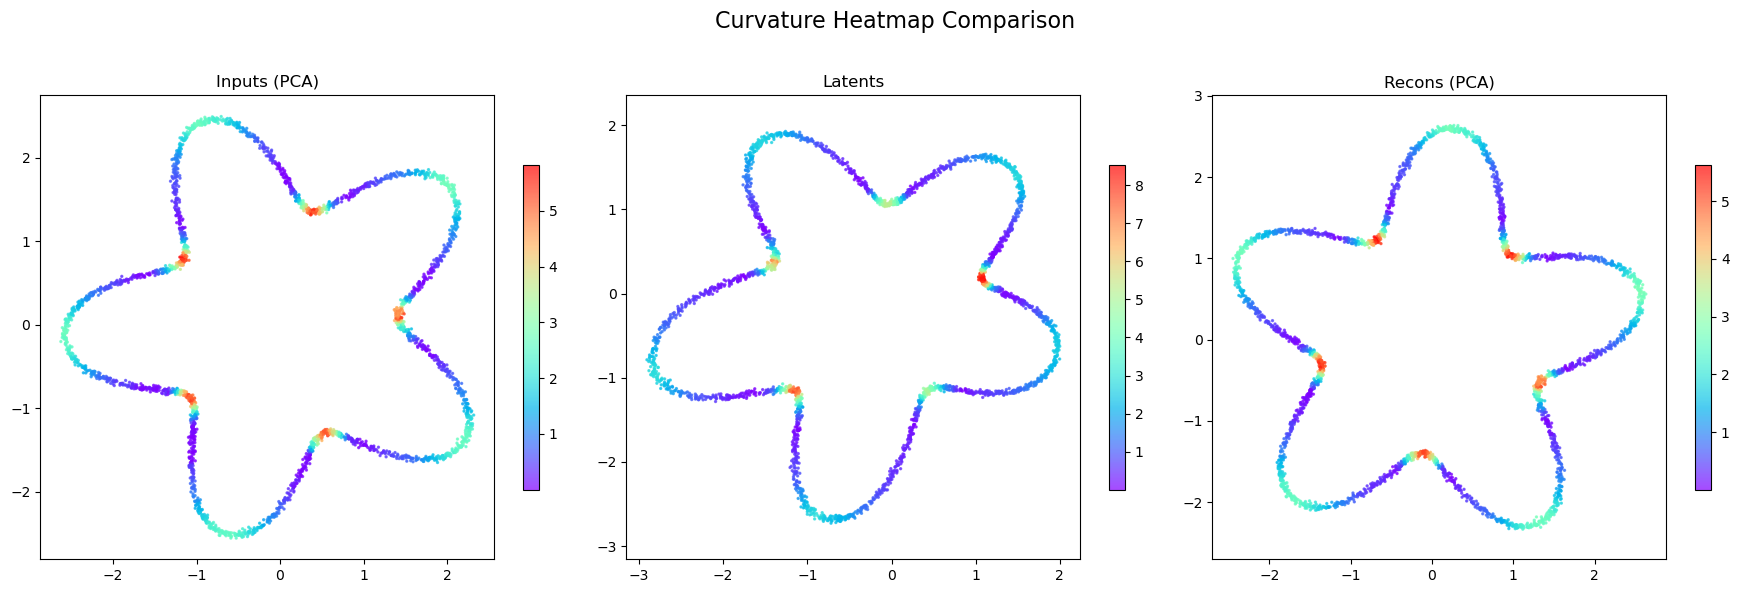

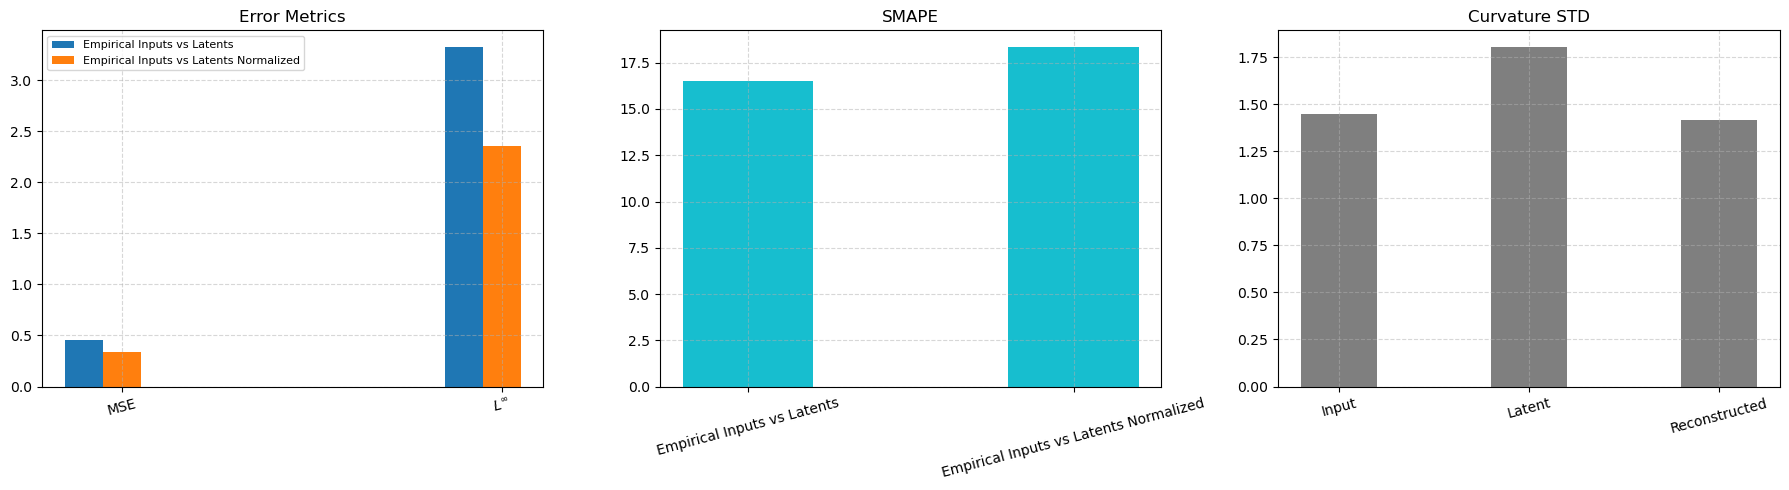

Execution time exp00_circle_low_for_plotting: 103.6370 seconds

Running exp01_circle_low_for_plotting. 
Description: alpha=1, gamma=1, dim_topo_loss=0
--------------------------------------------------------------------------------------


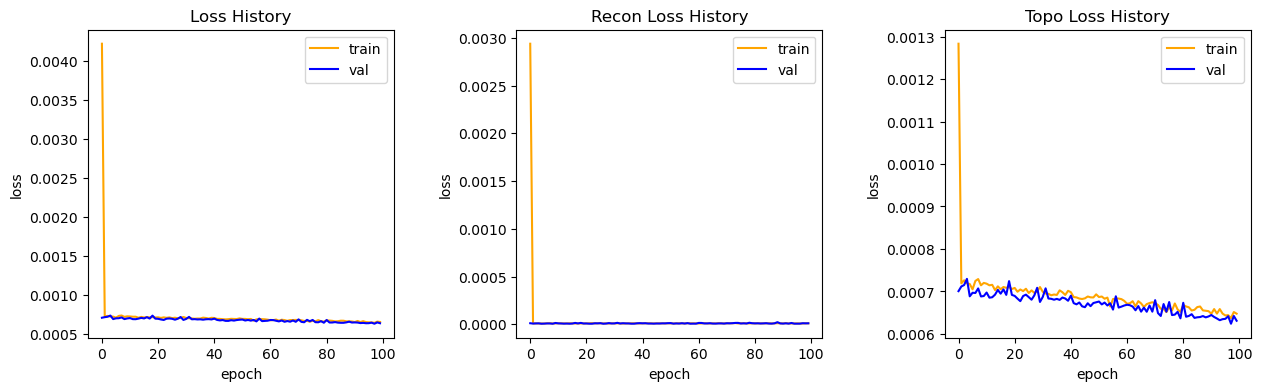

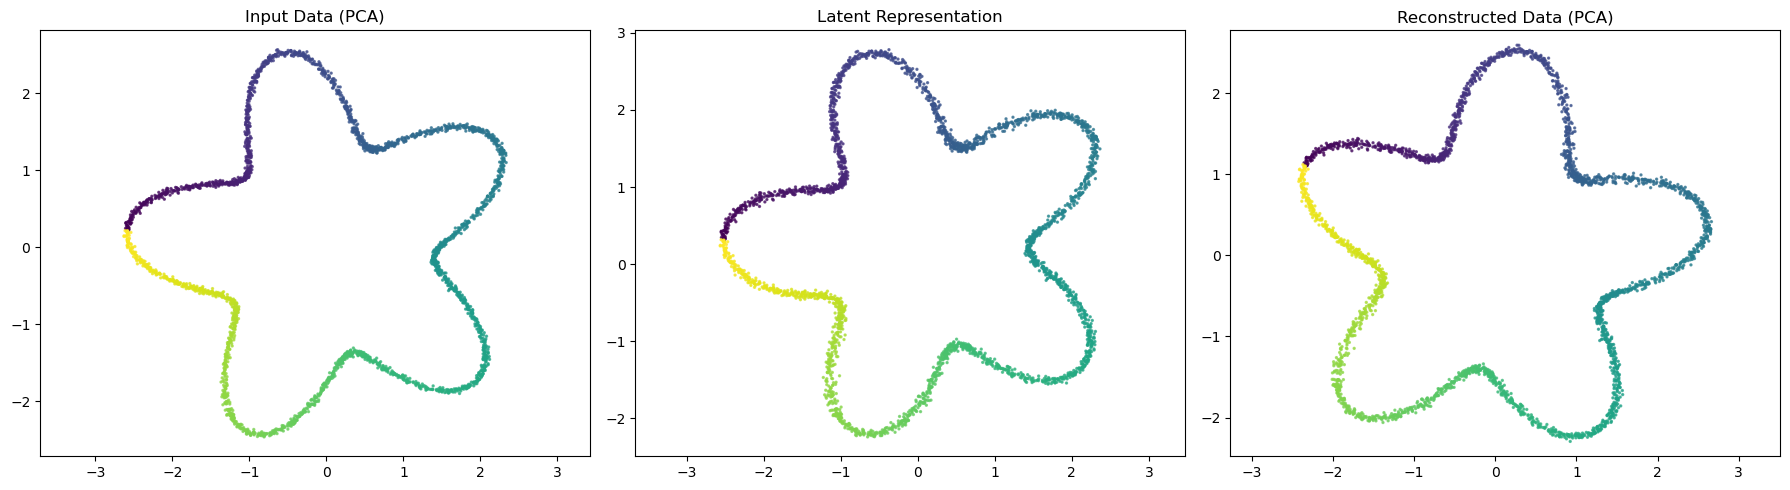

Estimating 1D curvature: 100%|████████████| 3000/3000 [00:02<00:00, 1346.36it/s]


<Figure size 640x480 with 0 Axes>

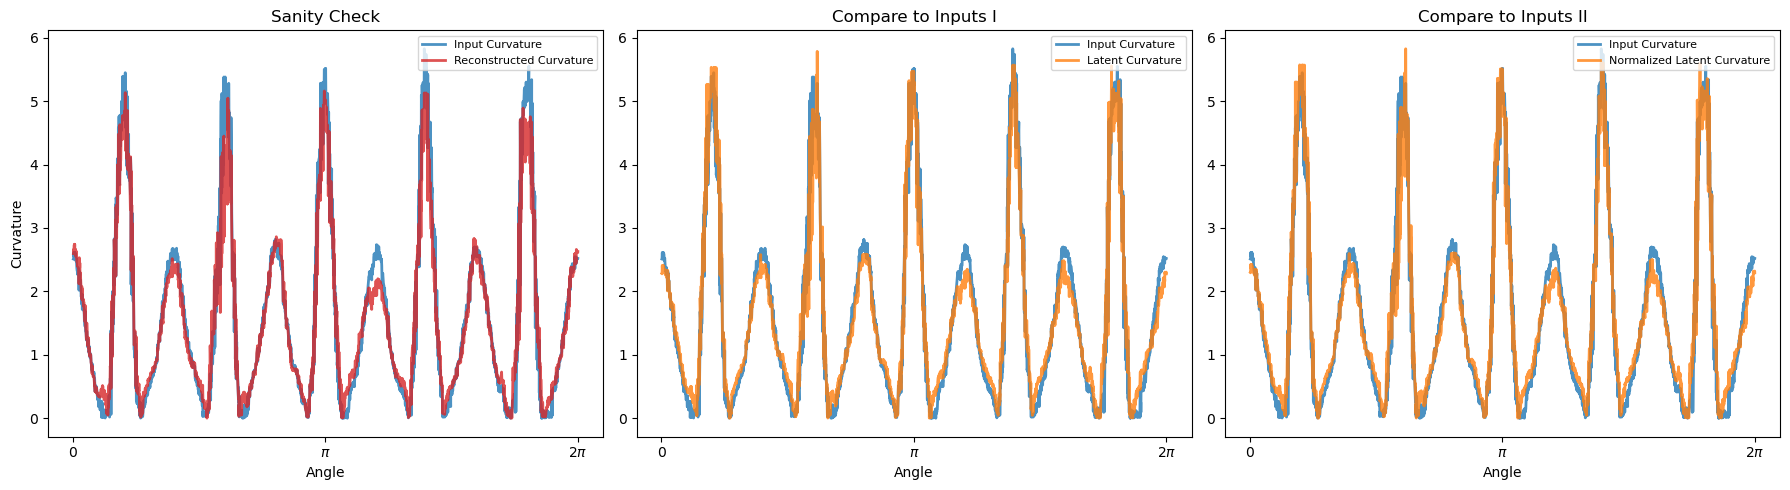

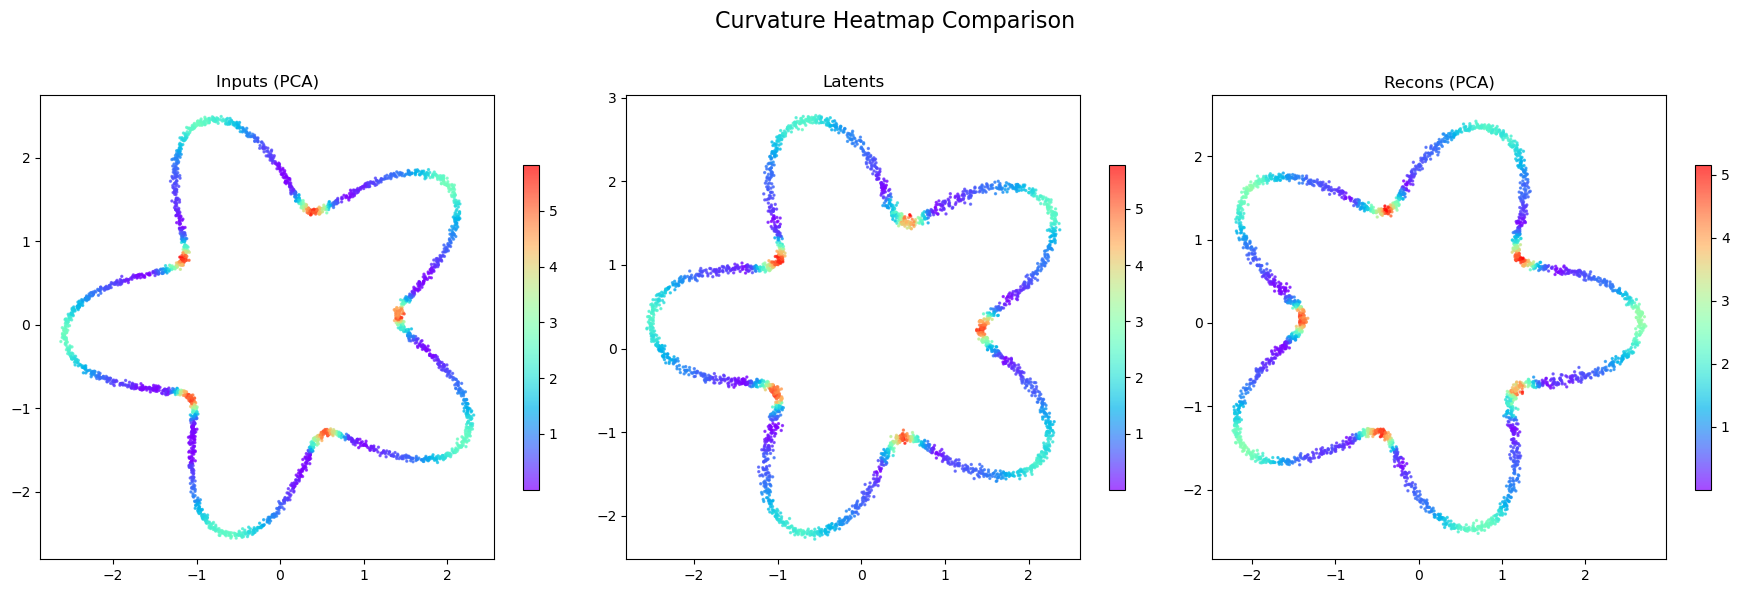

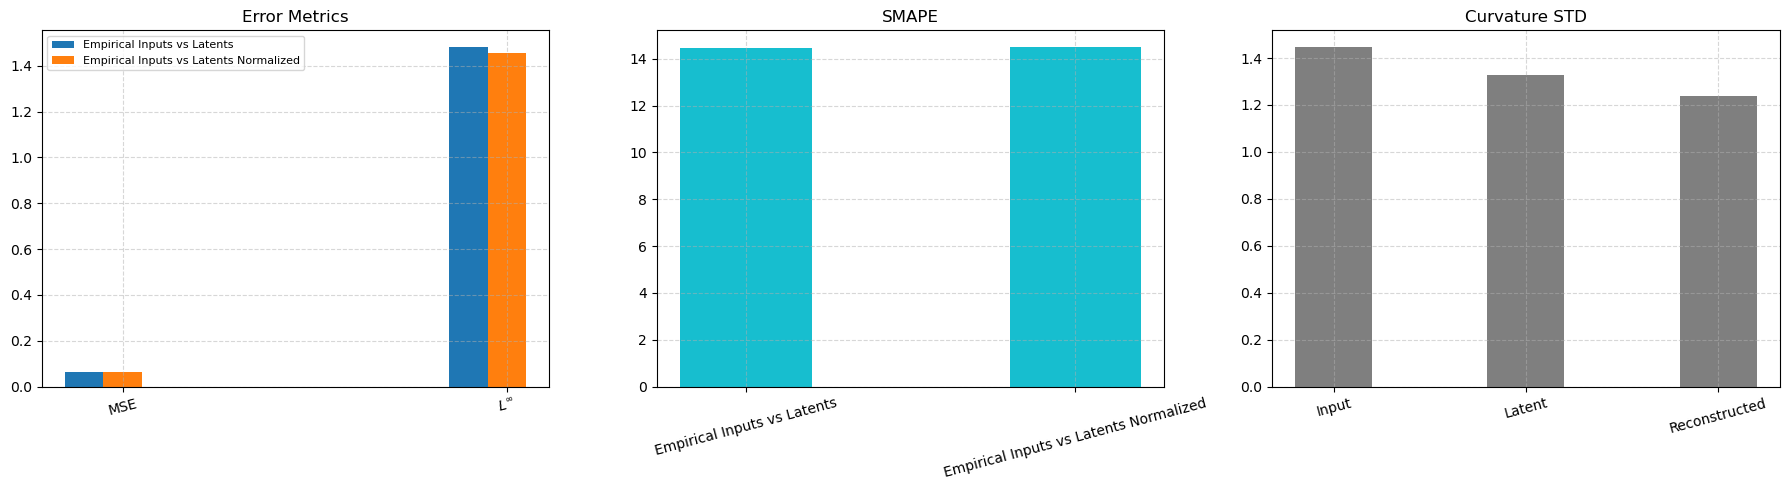

Execution time exp01_circle_low_for_plotting: 216.5180 seconds

Running exp02_circle_low_for_plotting. 
Description: alpha=0, gamma=1, dim_topo_loss=0
--------------------------------------------------------------------------------------


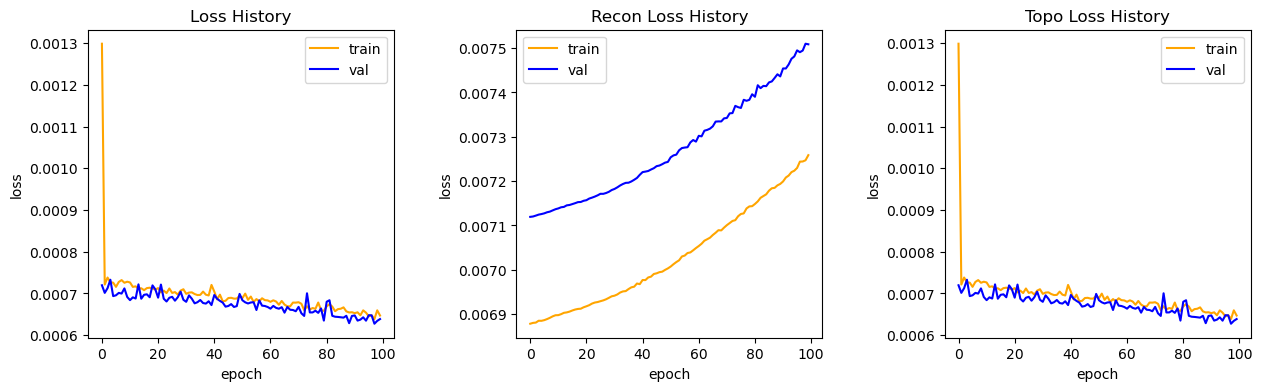

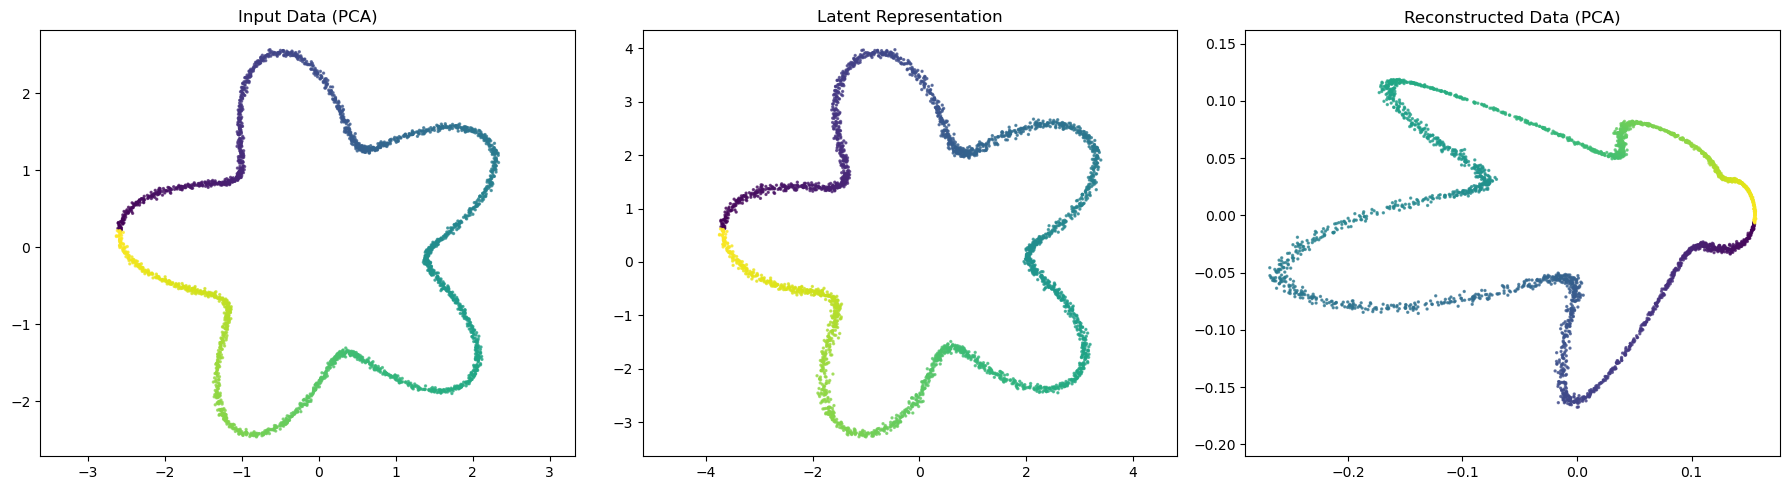

Estimating 1D curvature: 100%|████████████| 3000/3000 [00:02<00:00, 1198.22it/s]


<Figure size 640x480 with 0 Axes>

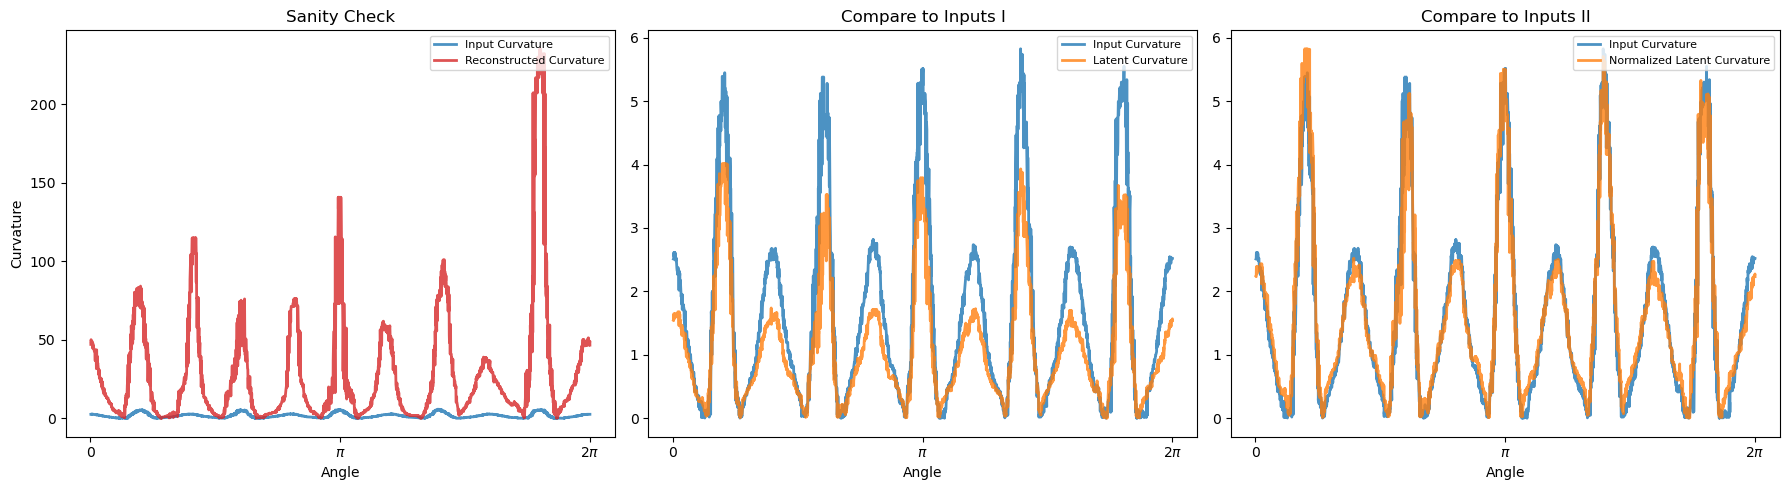

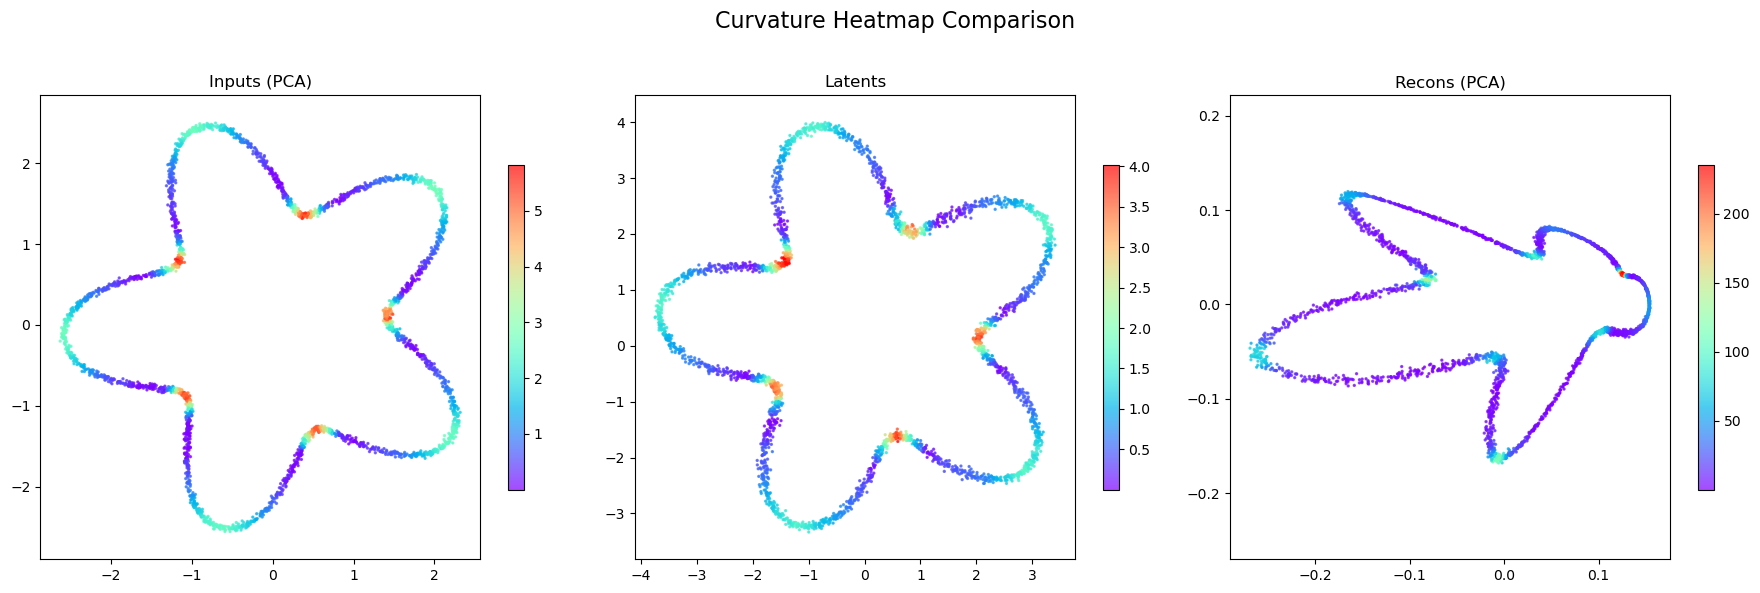

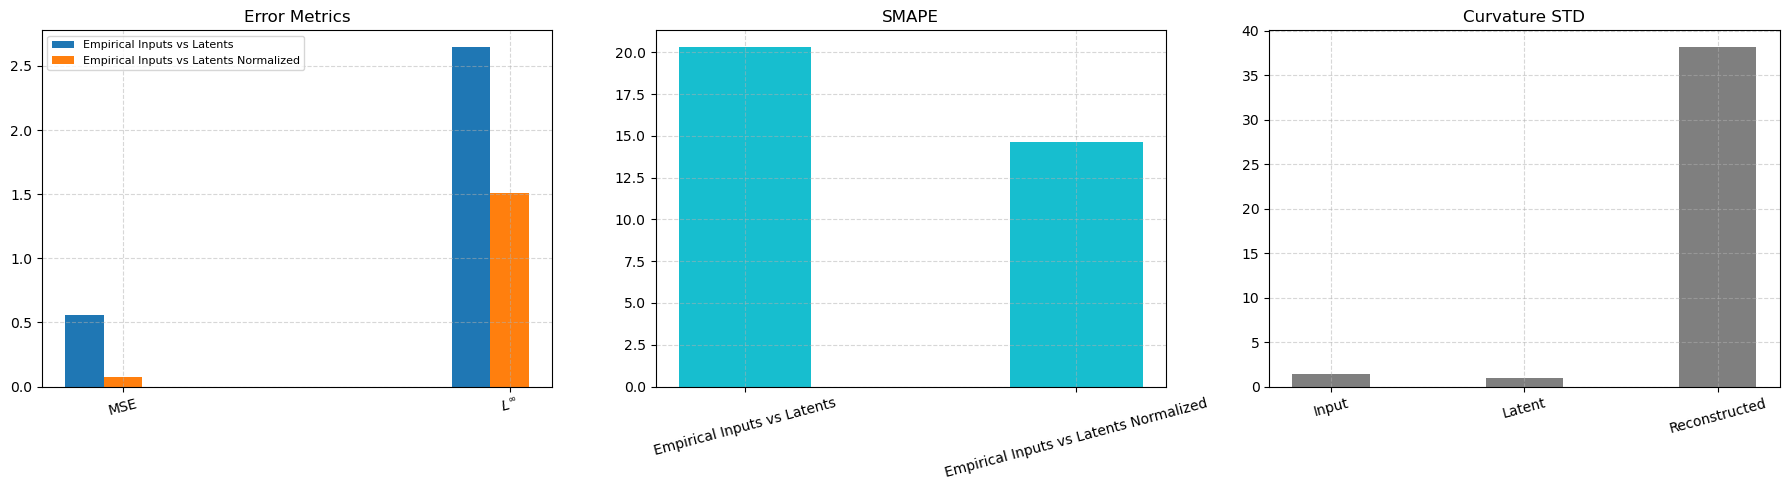

Execution time exp02_circle_low_for_plotting: 335.6702 seconds

Running exp03_circle_low_for_plotting. 
Description: alpha=1, gamma=1, dim_topo_loss=1
--------------------------------------------------------------------------------------


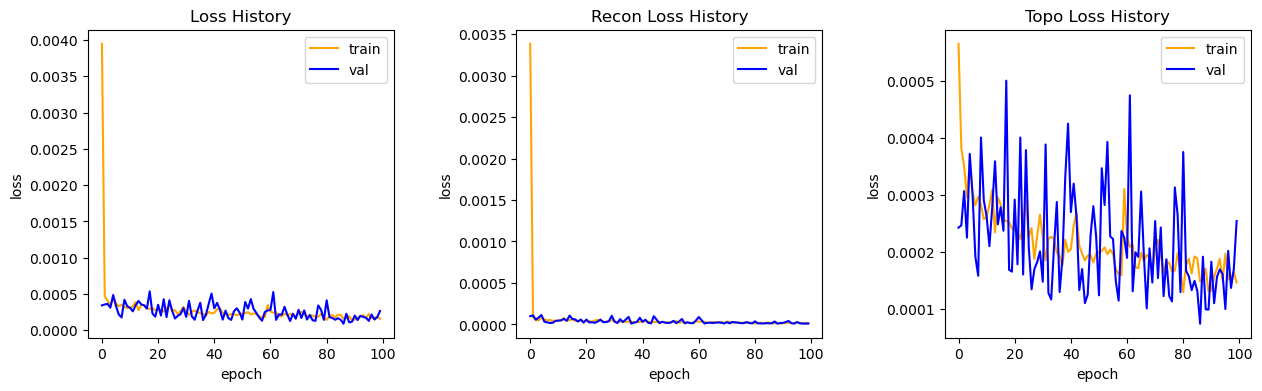

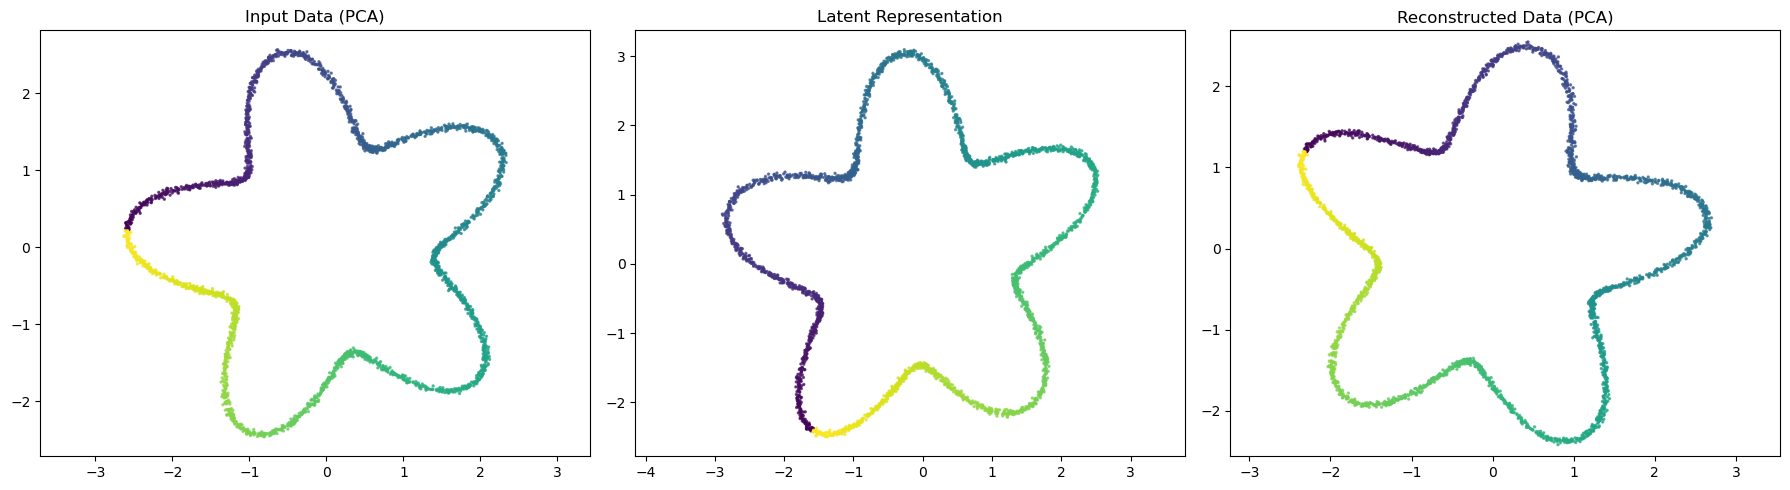

Estimating 1D curvature: 100%|████████████| 3000/3000 [00:02<00:00, 1262.20it/s]


<Figure size 640x480 with 0 Axes>

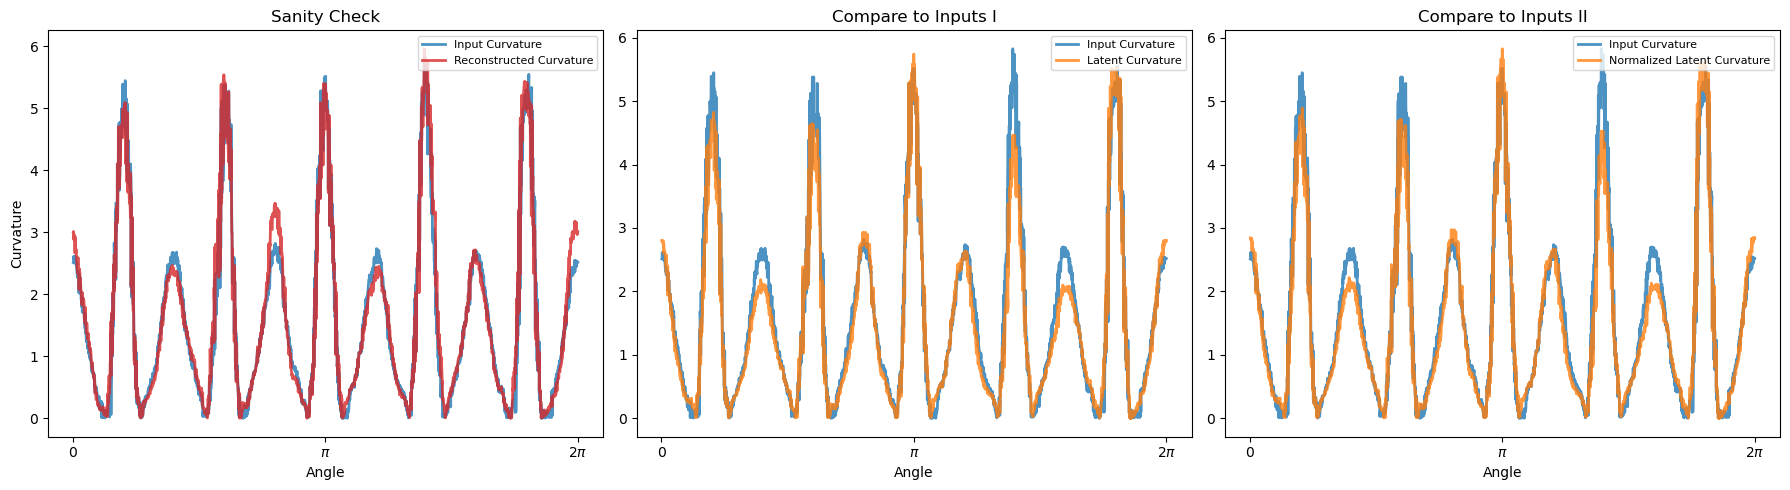

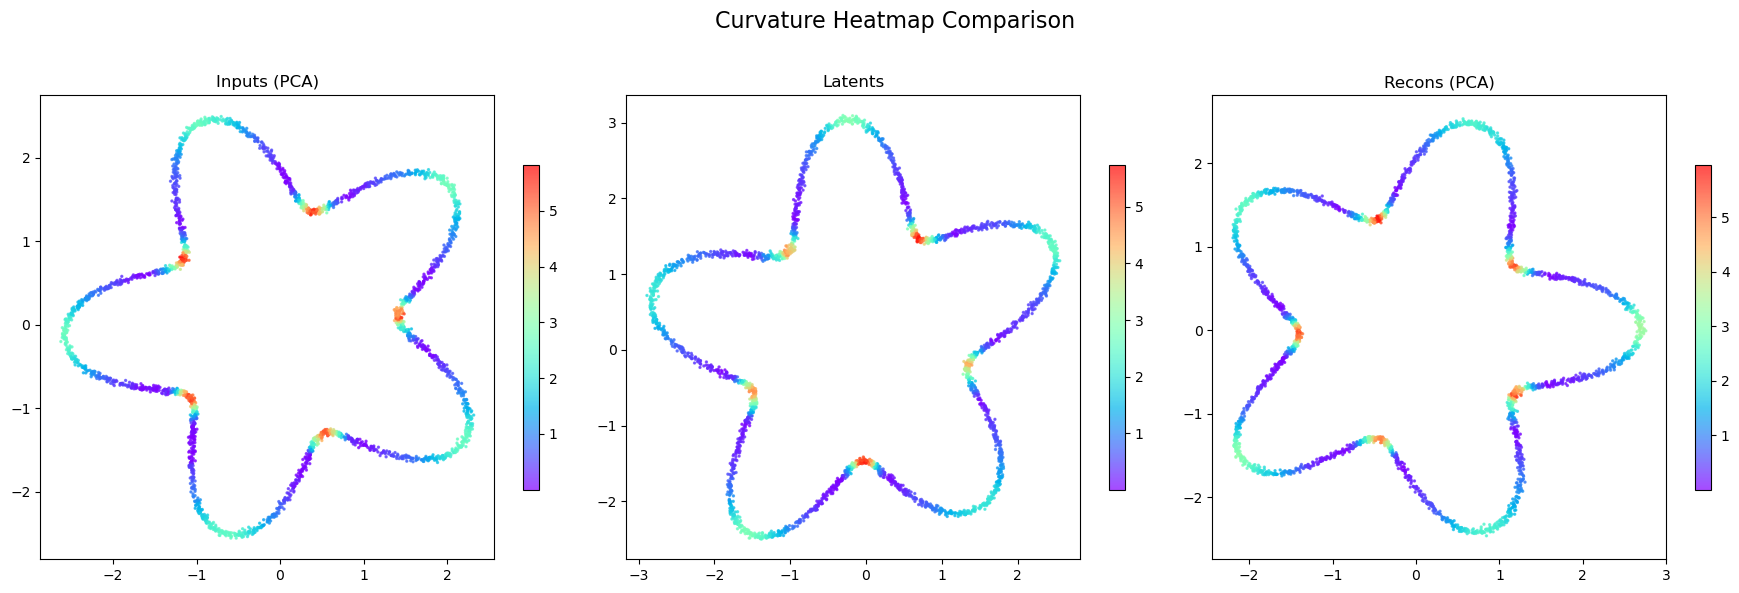

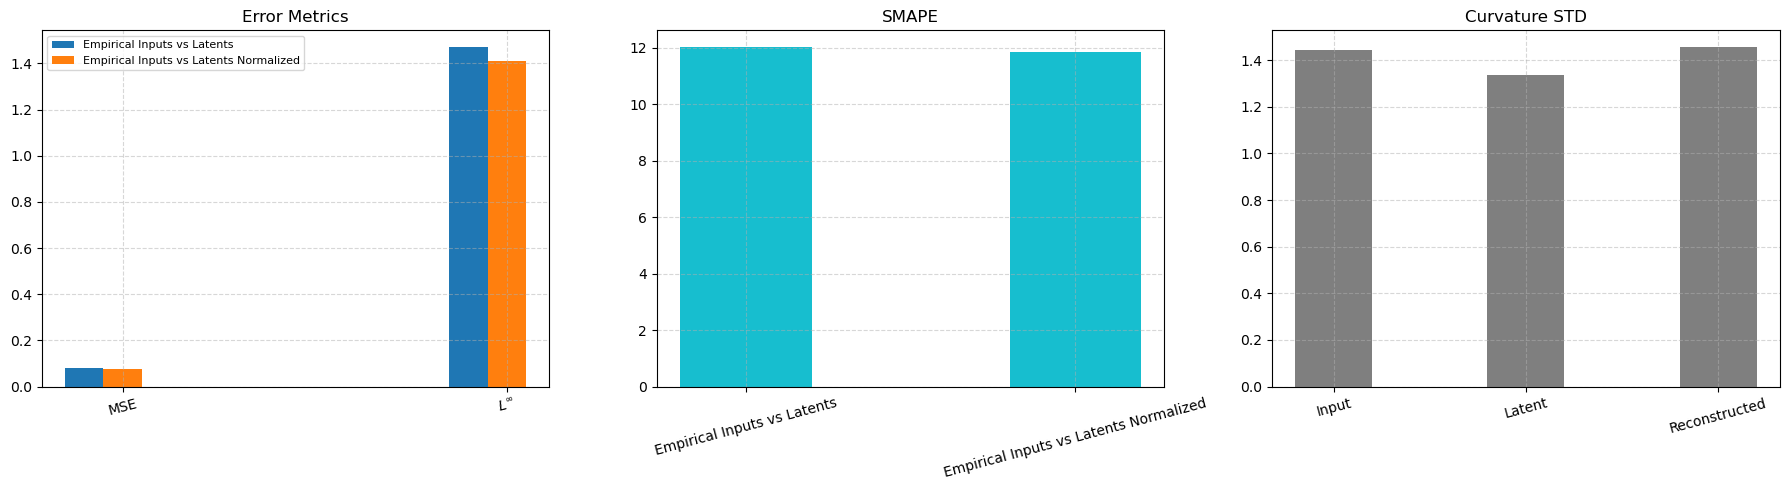

Execution time exp03_circle_low_for_plotting: 490.3054 seconds

Running exp04_circle_low_for_plotting. 
Description: alpha=0, gamma=1, dim_topo_loss=1
--------------------------------------------------------------------------------------


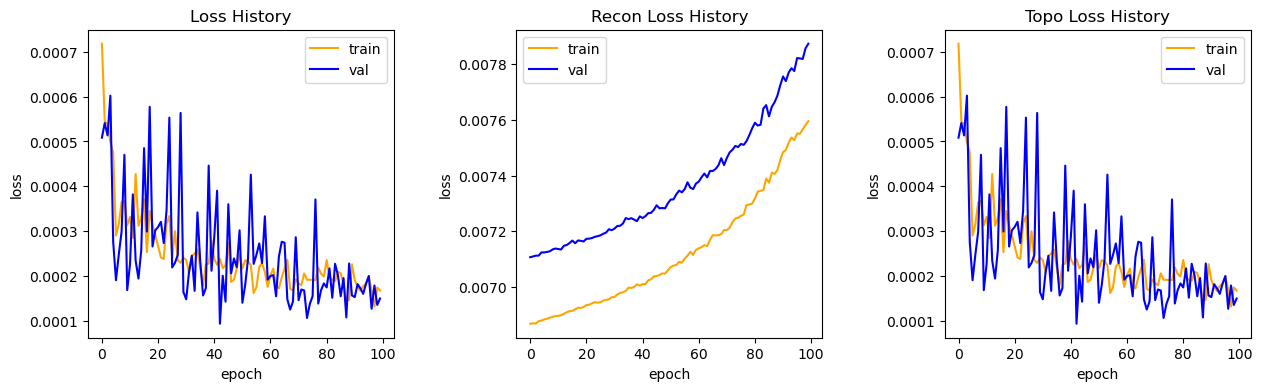

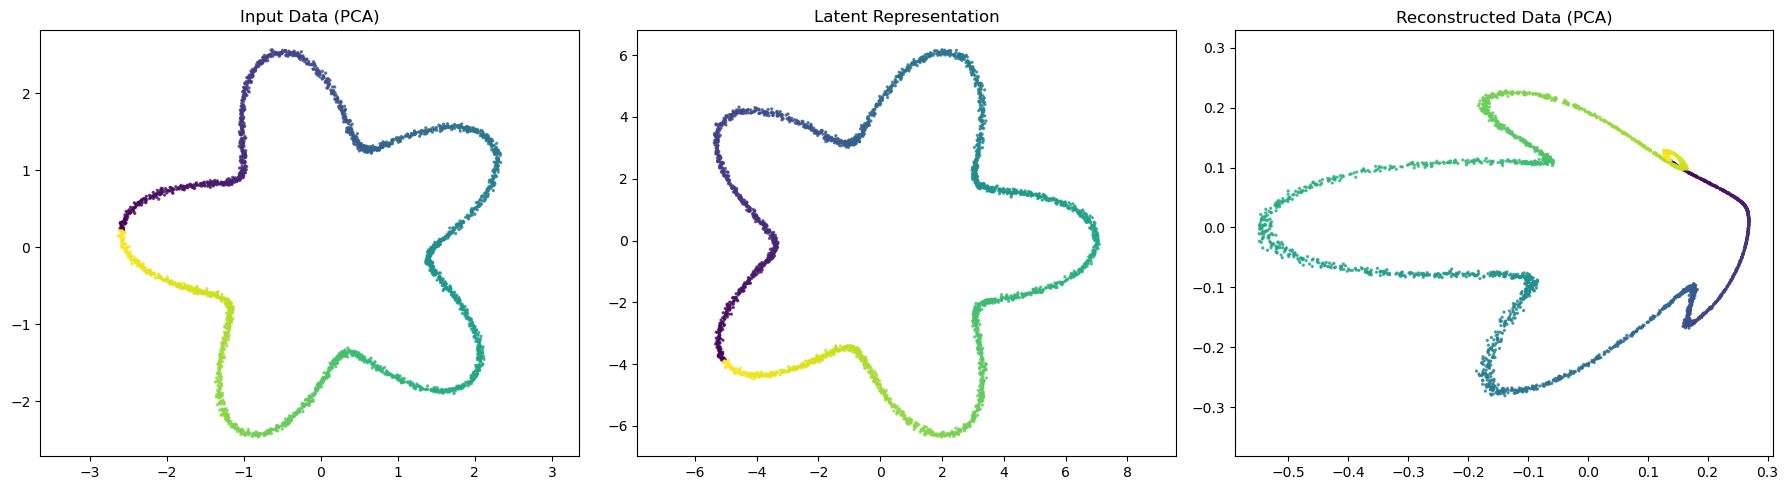

Estimating 1D curvature: 100%|█████████████| 3000/3000 [00:03<00:00, 894.83it/s]


<Figure size 640x480 with 0 Axes>

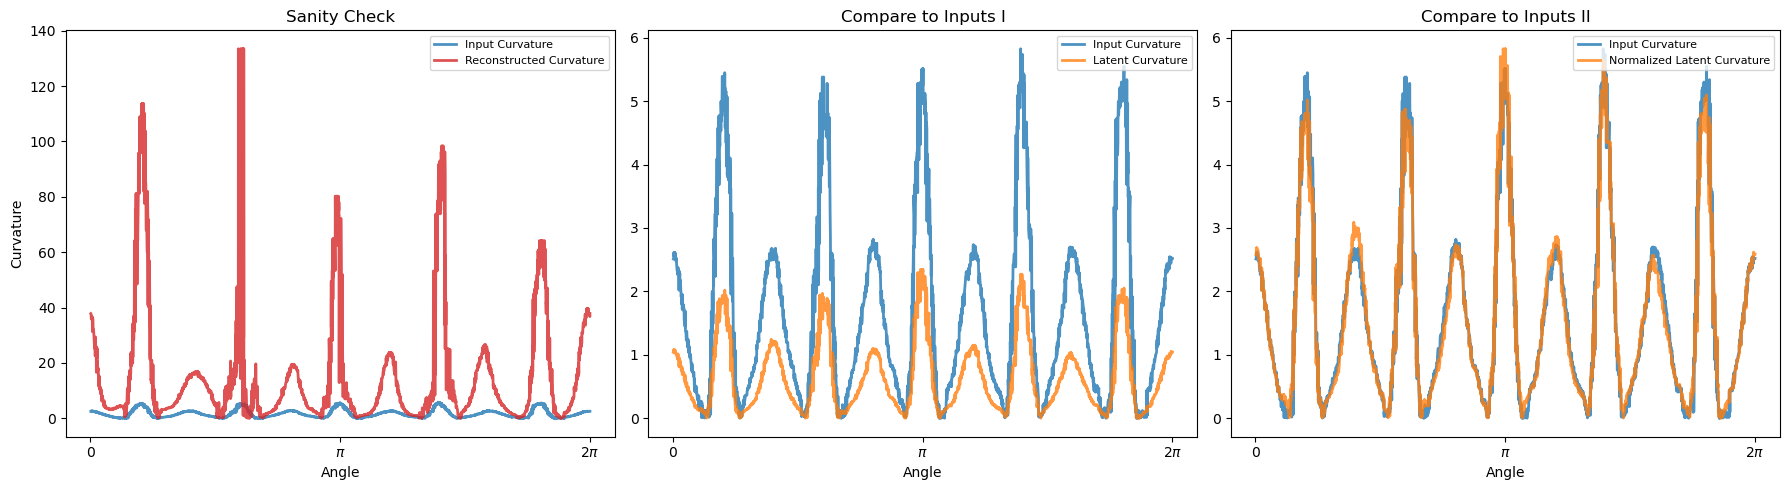

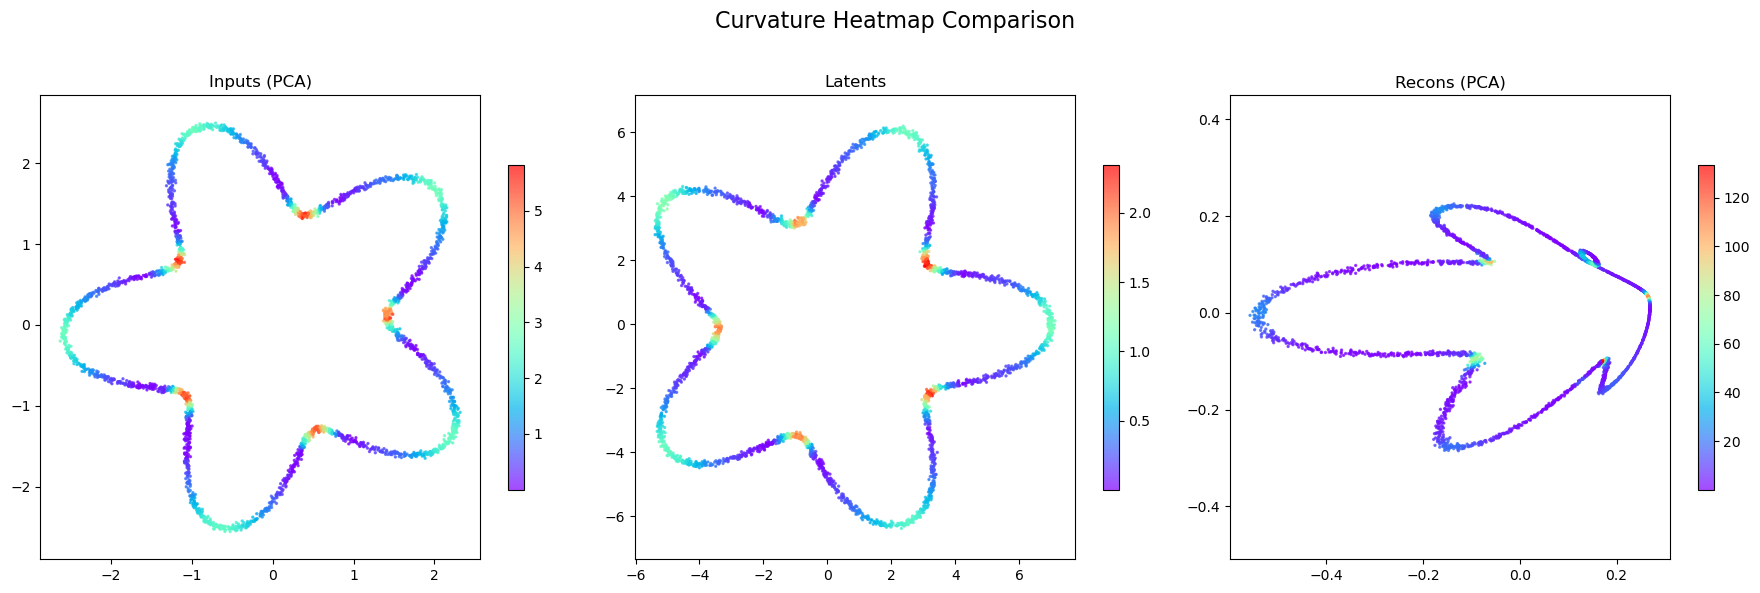

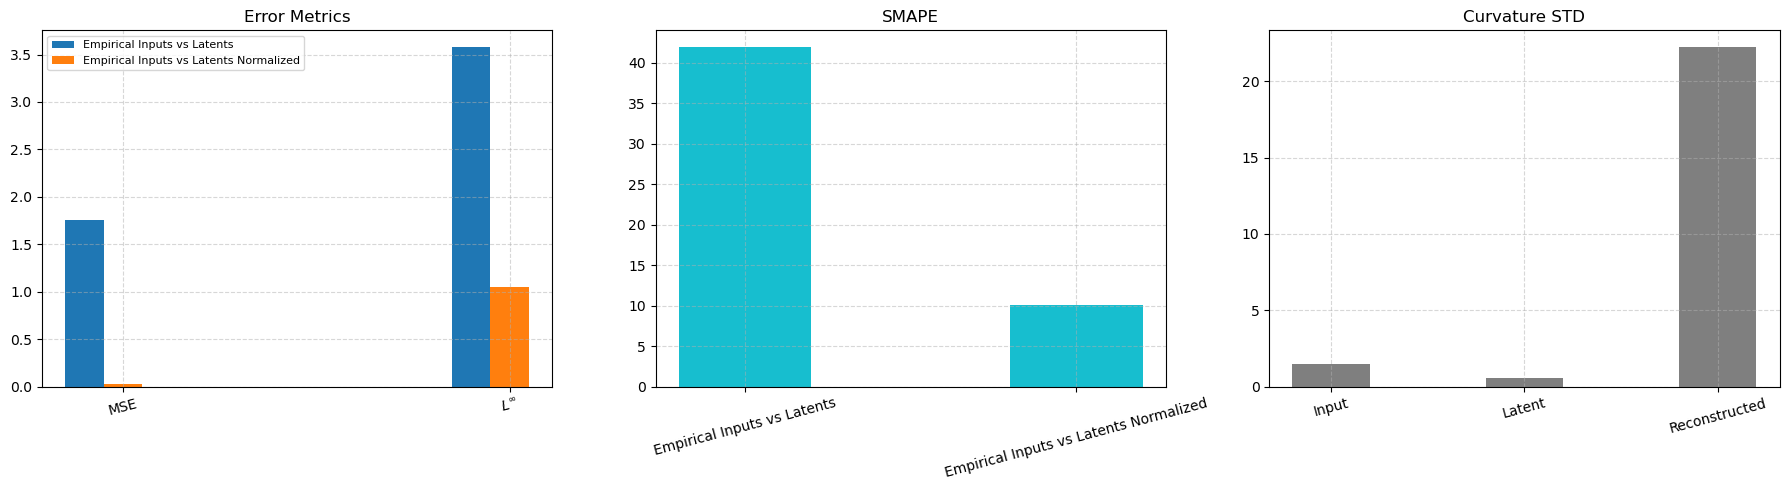

Execution time exp04_circle_low_for_plotting: 646.8883 seconds


In [5]:
run_experiment(all_configs=all_configs)